# LUCiD quickstart — simulate one event and see it

The 5-minute intro. LUCiD is a **differentiable** optical-photon simulator + fitter for
water-Cherenkov / neutrino-telescope detectors. Here we propagate one muon through SK-like water
and draw the per-PMT charge on the canonical unrolled-cylinder display — all via the library, no
inline machinery.

**Where to go next** (each notebook demonstrates one library seam):
`reconstruction/reconstruct_a_track` · `calibration/calibrate_optics` ·
`gradients/loss_landscapes` · `displays/event_displays`. For ≤20-line scripts see `../examples/`.

In [1]:
import sys; sys.path.append('..')
import jax, numpy as np
from lucid.simulation import setup_event_simulator
from lucid.detector_params import ParticleParams
from lucid.visualization import create_detector_display

GEOM, PHYS = '../config/SK_like_geom_config.json', '../config/SK_like_physics_config.json'
# full grid so every PMT is reachable (a coarse grid drops sensors -> white holes in the display)
sim = setup_event_simulator(GEOM, 200_000, K=4, physics_config=PHYS, default_detector_params=True,
                            particle='muon', n_cap=150, n_angular=250, n_height=150)

### Simulate — a 1 GeV muon fired horizontally from the centre (lights a barrel ring)

In [2]:
track = ParticleParams.from_cartesian(energy=1000., position=[0., 0., 0.],
                                      direction=[1., 0., 0.], t0=0.)
charge = np.asarray(sim(track, jax.random.PRNGKey(0))[3])      # (n_sensors,) per-PMT charge (pe)
print(f'{(charge > 0).sum()} of {charge.size} PMTs lit | total charge {charge.sum():.0f} pe')

10764 of 10764 PMTs lit | total charge 4514 pe


### Display — the canonical unrolled cylinder (barrel strip + top/bottom cap discs)

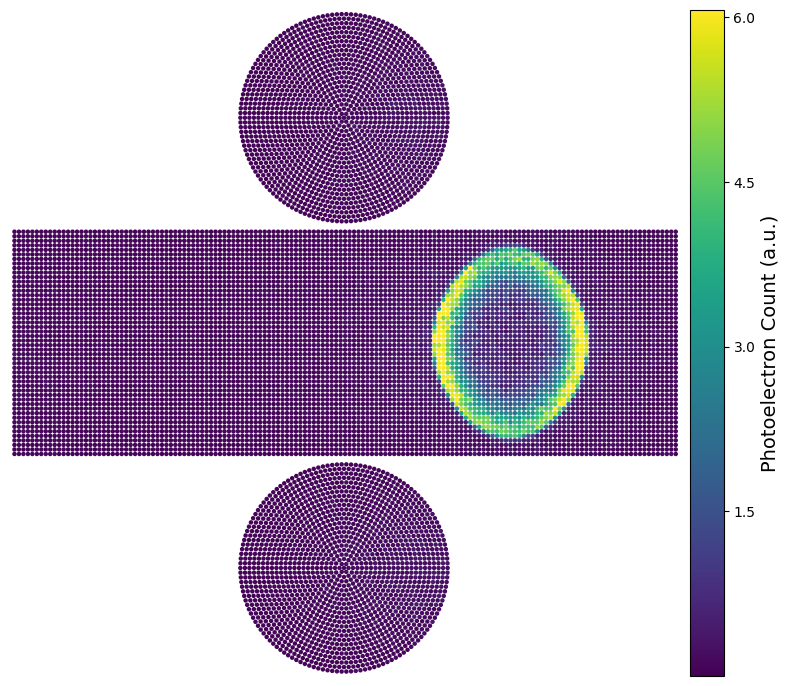

In [3]:
display = create_detector_display(GEOM, sparse=False)
display(charge, np.zeros_like(charge), file_name=None, perc_min=0.0, perc_max=99.5)

That Cherenkov ring is the raw observable everything else is built on:
**reconstruction** fits a track to it, **calibration** fits the detector optics to controlled
light, and the **gradients** notebooks show how the loss varies as you move the track. Continue
with `reconstruction/reconstruct_a_track.ipynb`.